# Patent Countries — PatentsView and PATSTAT side by side

Where patented inventions come from, on the two patent indices of this project, under one set of definitions:

| series | unit | year | country of a document |
|---|---|---|---|
| **PatentsView grants** | US utility grant (`patent_id`) | grant year | ISO2 of the inventor addresses printed on the grant |
| **PATSTAT applications** | application at any office (`appln_id`) | filing year | `person_ctry_code` of the inventors on that application |
| **PATSTAT families** | DOCDB family (`docdb_family_id`) | earliest priority year | the inventors of one representative member (`inv_appln_id`: the member with the most located inventors) |
| **PATSTAT families, filled** | as above | as above | as above; a family with no located inventor gets the country of its office of first filing when that office is national |

Shares use **fractional counting**: a document whose located inventors sit in two countries in a 3 : 1 split counts
0.75 and 0.25, so every located document carries weight 1 and the shares of a year sum to 100 %.

**Read the series as different questions.** PatentsView is the US record: 99 % of grants print an inventor address,
and foreign inventors appear only when they patent in the US. PATSTAT is worldwide but has an inventor address only
where the office records one — essentially every US, EP, WO and DE application, a few per cent of Chinese ones and
almost no Japanese ones — so a located-only PATSTAT share all but erases China and Japan. Applications count an
invention once per office it was filed at; families count it once. The **filled** family series gives an unlocated
family the country of its office of first filing (national offices only: EP, WO and the other regional routes are not
a country), the usual fallback when the inventor address is missing; every panel that uses it says so.

## Inputs
```
PatentView/output/patent_inventor_country.parquet, patent_metadata.parquet
PATSTAT/output/patstat_inventor_country.parquet, patstat_metadata.parquet            (applications, filing clock)
PATSTAT/output_family/patstat_inventor_country.parquet, patstat_metadata.parquet     (DOCDB families, priority year)
validation/data/world_countries.geojson                                               (maps)
```

In [1]:
import os, sys
import numpy as np, pandas as pd, duckdb
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

sys.path.insert(0, '/project/jevans/Dawoon/Science of Science/validation')
import val_common as V
V.init('patent_country_validation')
assert V.preflight('patent_country_validation'), 'an input is missing -- see the list above'

PV_LAST = 2025                # PatentsView grants run 1976-2025
SNAP_PS = 2023 - 2            # PATSTAT 2023 Autumn: filings and priorities of 2022-23 are not fully published yet
Y0 = 1980                     # PATSTAT inventor addresses are thin before 1980
# offices that are not a country: regional and international filing routes (EPO, PCT, Eurasian, ARIPO, OAPI, GCC,
# Nordic, Visegrad, WIPO, EUIPO)
REGIONAL = ('EP', 'WO', 'EA', 'AP', 'OA', 'GC', 'XN', 'XV', 'IB', 'EM', 'EU')
SEQ, DIV = 'Blues', 'RdBu_r'
INK, MUTED, GRID, SURFACE, NODATA = '#0b0b0b', '#52514e', '#e6e5e1', '#fcfcfb', '#cfd2d6'
# series colours: the first three slots of the categorical palette (they separate under every colour-vision type);
# the filled family series is the family series drawn dashed / hatched, not a fourth hue
BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
SERIES = {'pv': ('PatentsView grants', BLUE, '-'), 'pa': ('PATSTAT applications', ORANGE, '-'),
          'pf': ('PATSTAT families', AQUA, '-'), 'pff': ('PATSTAT families, filled', AQUA, '--')}
YEAR_LABEL = {'pv': 'grant year', 'pa': 'filing year', 'pf': 'priority year', 'pff': 'priority year'}
LAST = {'pv': PV_LAST, 'pa': SNAP_PS, 'pf': SNAP_PS, 'pff': SNAP_PS}
# PatentsView 1976-79 locates only 76-84 % of grants (the early location table is incomplete), which inflates the
# US share of the located ones; shares and counts start in 1980 on every series, the coverage panel shows 1976-79
FIRST = {'pv': Y0, 'pa': Y0, 'pf': Y0, 'pff': Y0}
# eight country slots in the palette's fixed order, then "other" and "unlocated" in neutrals
CAT8 = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
OTHER, UNLOC = '#a3a19b', '#e6e5e1'

def style(ax, xlab=None, ylab=None, title=None):
    ax.set_facecolor(SURFACE); ax.grid(axis='y', color=GRID, lw=.8, zorder=0)
    ax.set_axisbelow(True); ax.tick_params(colors=MUTED, length=3)
    for sp in ax.spines.values():
        sp.set_color(GRID)
    if xlab: ax.set_xlabel(xlab, color=MUTED)
    if ylab: ax.set_ylabel(ylab, color=MUTED)
    if title: ax.set_title(title, color=INK, loc='left', pad=8, fontsize=10)
    return ax

def q(sql):
    return con.execute(sql).fetchdf()

con = duckdb.connect()
con.execute(f"SET memory_limit='{os.environ.get('NB_DUCKDB_MEM', '160GB')}'")
con.execute(f"SET threads={int(os.environ.get('SLURM_CPUS_PER_TASK', '8'))}")
TMPDIR = f'{V.TMP}/patent_country_validation_{os.getpid()}'          # never share a spill folder
os.makedirs(TMPDIR, exist_ok=True); con.execute(f"SET temp_directory='{TMPDIR}'")
con.execute('SET preserve_insertion_order=false'); con.execute('SET enable_progress_bar=false')

# --- world maps -------------------------------------------------------------------------
# Boundaries: validation/data/world_countries.geojson, Natural Earth 1:50m Admin 0 (public
# domain), trimmed to iso2/name/continent and simplified; see world_countries.source.json.
# The 1:50m cut is deliberate -- 1:110m omits Singapore, Hong Kong, Malta and Bahrain, all of
# which are real producers here, and a country missing from the map reads as a country with no
# output. Robinson, because an equirectangular world map inflates the high latitudes and this
# figure is about how much each country produces.
WORLD_FP = f'{V.VAL}/data/world_countries.geojson'
ROBINSON = '+proj=robin +lon_0=0 +datum=WGS84 +units=m +no_defs'

def load_world():
    """(GeoDataFrame in Robinson, {iso2: (lon, lat)}) or (None, None) if the file is absent."""
    try:
        import geopandas as gpd
    except ImportError:
        print('geopandas is not installed -- map sections skipped'); return None, None
    if not os.path.exists(WORLD_FP):
        print(f'{WORLD_FP} is missing -- map sections skipped.\n'
              '  Rebuild it from Natural Earth 1:50m Admin 0 Countries; see world_countries.source.json.')
        return None, None
    w = gpd.read_file(WORLD_FP)

    def rep(g):
        # the representative point of the LARGEST polygon, so the United States lands in the
        # lower 48 and France in France rather than in Alaska or French Guiana
        p = max(g.geoms, key=lambda q: q.area) if g.geom_type == 'MultiPolygon' else g
        return p.representative_point()

    pts = {r.iso2: (rep(r.geometry).x, rep(r.geometry).y) for r in w.itertuples()}
    return w.to_crs(ROBINSON), pts

def frame(ax, world):
    """Every panel gets the same extent, so the four maps are comparable and a stray arc is clipped."""
    x0, y0, x1, y1 = world.total_bounds
    mx, my = 0.02 * (x1 - x0), 0.04 * (y1 - y0)
    ax.set_xlim(x0 - mx, x1 + mx); ax.set_ylim(y0 - my, y1 + my)
    ax.set_axis_off()

def choropleth(ax, world, values, title, label, cmap=SEQ, norm=None):
    """values: Series indexed by ISO2. Countries with no value are drawn in the no-data grey."""
    g = world.merge(values.rename('v'), left_on='iso2', right_index=True, how='left')
    g.plot(ax=ax, column='v', cmap=cmap, norm=norm, linewidth=0.2, edgecolor='white',
           legend=True, legend_kwds={'orientation': 'horizontal', 'shrink': 0.62, 'pad': 0.01,
                                     'aspect': 34, 'label': label},
           missing_kwds={'color': NODATA, 'edgecolor': 'white', 'linewidth': 0.2})
    ax.set_title(title, fontsize=10, color=INK); frame(ax, world)
    return g

def map_coverage(values, world, what):
    """Say out loud which codes in the data have no polygon, and how much output they carry."""
    have = set(world['iso2'])
    miss = values[[c not in have for c in values.index]]
    if len(miss):
        share = 100 * miss.sum() / values.sum() if values.sum() else 0
        print(f'  {len(miss)} {what} code(s) have no polygon on the map '
              f'({share:.2f}% of the total): {", ".join(sorted(miss.index)[:20])}')
    else:
        print(f'  every {what} code in the data is on the map')

[val] patent_country_validation  ->  /project/jevans/Dawoon/Science of Science/validation/Figures/patent_country_validation_<section>.{jpg,pdf}  @ 600 dpi
  patent_country_validationOK


## 0. Base tables and integrity

One row per document of each index, `(year, office, cic, n_located, n_inventors, intl)`, built with a LEFT JOIN from
the metadata so a document without an inventor row counts as unlocated instead of disappearing. Then one weight table
per series, `(year, country, w)`, by fractional counting. Asserted: the joins do not fan out (one row per metadata
row), and every located document carries total weight 1 — so a year's weights sum to its located documents.

In [2]:
%%time
con.execute(f"""CREATE OR REPLACE TABLE pv AS
  SELECT m.grant_year AS year, 'US' AS office, ic.country_inventor_counts AS cic, coalesce(ic.n_located, 0) AS n_located,
         coalesce(ic.n_inventors, 0) AS n_inventors, coalesce(ic.is_international, false) AS intl
  FROM read_parquet('{V.patent('patent_metadata.parquet')}') m
  LEFT JOIN read_parquet('{V.patent('patent_inventor_country.parquet')}') ic USING (patent_id)""")
for name, P, year_col, key in (('pa', V.patstat, 'filing_year', 'appln_id'),
                               ('pf', V.patstat_family, 'priority_year', 'docdb_family_id')):
    con.execute(f"""CREATE OR REPLACE TABLE {name} AS
      SELECT m.{year_col} AS year, m.appln_auth AS office, ic.country_inventor_counts AS cic, coalesce(ic.n_located, 0) AS n_located,
             coalesce(ic.n_inventors, 0) AS n_inventors, coalesce(ic.is_international, false) AS intl
      FROM read_parquet('{P('patstat_metadata.parquet')}') m
      LEFT JOIN read_parquet('{P('patstat_inventor_country.parquet')}') ic USING ({key})""")
META = {'pv': V.patent('patent_metadata.parquet'), 'pa': V.patstat('patstat_metadata.parquet'),
        'pf': V.patstat_family('patstat_metadata.parquet')}
rows = []
for t in ('pv', 'pa', 'pf'):
    n_meta = con.execute(f"SELECT count(*) FROM read_parquet('{META[t]}')").fetchone()[0]
    n, loc = con.execute(f'SELECT count(*), count(*) FILTER (WHERE n_located > 0) FROM {t}').fetchone()
    assert n == n_meta, f'{t}: the inventor-country join fanned out ({n:,} rows for {n_meta:,} documents)'
    rows.append(dict(series=SERIES[t][0], documents=n, located=loc, located_pct=round(100 * loc / n, 1)))
display(pd.DataFrame(rows))

def weights(t, fill=False):
    """(year, country, w): fractional inventor-country weights of the located documents of table t.
    fill=True adds weight 1 on the office of first filing for an unlocated document filed at a national office."""
    extra = (f"""UNION ALL SELECT year, office AS country, 1.0 AS w FROM {t}
                 WHERE n_located = 0 AND regexp_full_match(office, '[A-Z]{{2}}') AND office NOT IN {REGIONAL}""" if fill else '')
    return f"""SELECT year, country, sum(w) AS w FROM (
                 SELECT year, split_part(x, ':', 1) AS country, split_part(x, ':', 2)::DOUBLE / n_located AS w
                 FROM (SELECT year, n_located, unnest(str_split(cic, ';')) AS x FROM {t} WHERE n_located > 0)
                 {extra}) GROUP BY 1, 2"""

for k, t, fill in (('pv', 'pv', False), ('pa', 'pa', False), ('pf', 'pf', False), ('pff', 'pf', True)):
    con.execute(f'CREATE OR REPLACE TABLE w_{k} AS {weights(t, fill)}')
chk = []
for k, t, fill in (('pv', 'pv', False), ('pa', 'pa', False), ('pf', 'pf', False), ('pff', 'pf', True)):
    w = con.execute(f'SELECT sum(w) FROM w_{k}').fetchone()[0]
    filled = (f"count(*) FILTER (WHERE n_located = 0 AND regexp_full_match(office, '[A-Z]{{2}}') AND office NOT IN {REGIONAL})"
              if fill else '0')
    expect = con.execute(f'SELECT count(*) FILTER (WHERE n_located > 0) + {filled} FROM {t}').fetchone()[0]
    assert abs(w - expect) < 1e-6 * max(expect, 1), f'{k}: weights {w:,.1f} != documents {expect:,}'
    chk.append(dict(series=SERIES[k][0], total_weight=round(w), documents_with_a_country=expect,
                    countries=con.execute(f'SELECT count(DISTINCT country) FROM w_{k}').fetchone()[0]))
display(pd.DataFrame(chk))

def shares(k, y0=None, y1=None):
    """year x country share (%) of the series' weight in that year."""
    d = q(f'SELECT year, country, w FROM w_{k} WHERE year BETWEEN {y0 or FIRST[k]} AND {y1 or LAST[k]}')
    s = d.pivot_table(index='year', columns='country', values='w', aggfunc='sum').fillna(0)
    return s.div(s.sum(axis=1), axis=0) * 100

S = {k: shares(k) for k in SERIES}
recent = lambda k: S[k].loc[2010:2019].mean()
# the eight countries that get a colour of their own everywhere in this notebook: largest by the mean of their
# PatentsView and filled-family shares in 2010-2019, so both views are represented
comb = (recent('pv').reindex(recent('pff').index.union(recent('pv').index)).fillna(0)
        + recent('pff').reindex(recent('pff').index.union(recent('pv').index)).fillna(0)) / 2
TOP8 = comb.nlargest(8).index.tolist()
COLOR = dict(zip(TOP8, CAT8))
print('countries with their own colour:', TOP8)

,series,documents,located,located_pct
0,PatentsView grants,8531961,8474359,99.3
1,PATSTAT applications,84914026,35618480,41.9
2,PATSTAT families,52766567,18728195,35.5


,series,total_weight,documents_with_a_country,countries
0,PatentsView grants,8474359,8474359,200
1,PATSTAT applications,35618480,35618480,338
2,PATSTAT families,18728195,18728195,309
3,"PATSTAT families, filled",52735021,52735021,309


countries with their own colour: ['US', 'CN', 'JP', 'KR', 'DE', 'TW', 'GB', 'FR']
CPU times: user 52.3 s, sys: 3.17 s, total: 55.5 s
Wall time: 10.3 s


## 1. Coverage — how much of each index has an inventor country

Left: the share of documents with at least one located inventor, by year, for the three series, plus the filled family
series (dashed) — the share of families that get a country at all. Right: PATSTAT families with a located inventor by
office of first filing, priority 2000–2019. This is the panel that decides which country comparisons PATSTAT can
support on its own: the US, Europe and the PCT route are fully located; China and Japan are not, which is why the
later sections carry the filled series. Families are located *less* often than applications overall, although one
located member locates its family: a multi-office family, usually located through its US, EP or WO member, collapses
many located applications into one row, while a domestic-only Chinese or Japanese family, mostly unlocated, stays one
row. PatentsView locates only 76–84 % of its 1976–79 grants, so its series start in 1980 everywhere else.

  [fig] patent_country_validation_1.jpg + .pdf  (600 dpi)


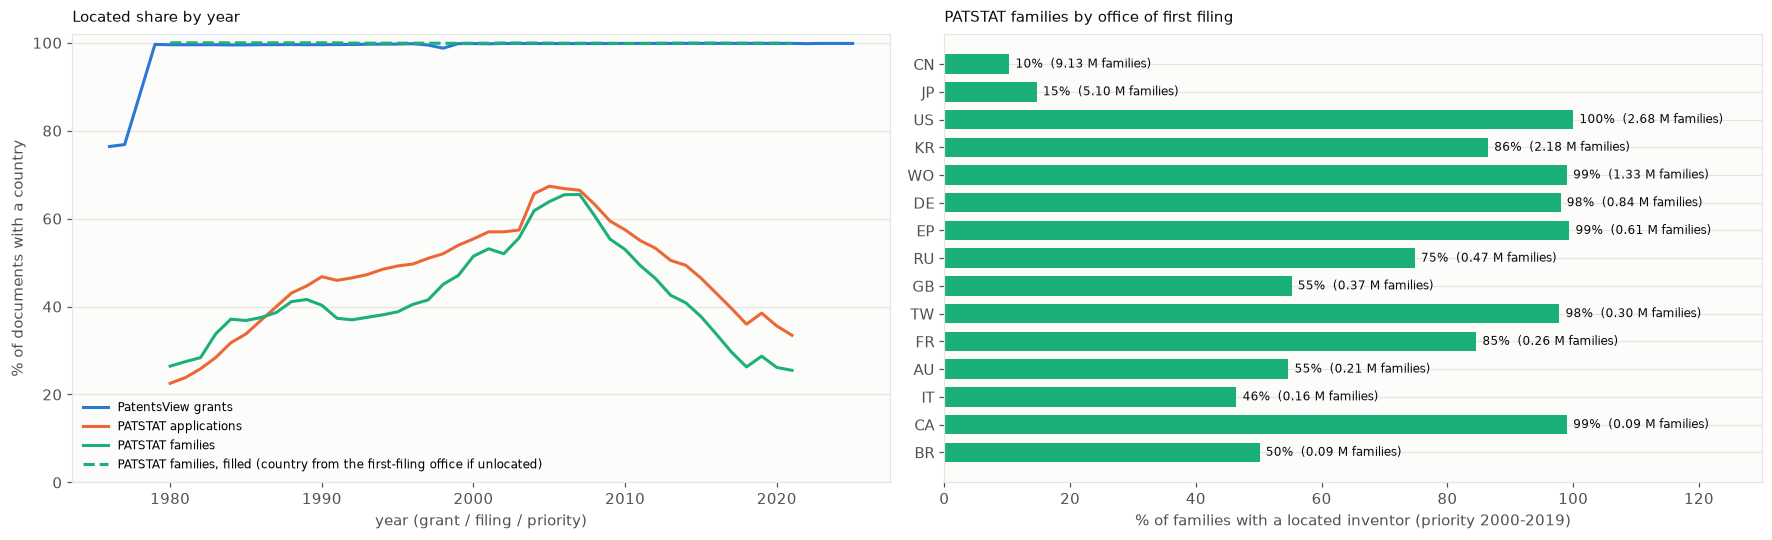

,PatentsView grants,PATSTAT applications,PATSTAT families,"PATSTAT families, filled"
year,,,,
1980,99.6,22.5,26.4,100.0
1990,99.6,46.8,40.3,100.0
2000,99.8,55.4,51.5,99.9
2010,99.9,57.4,53.0,99.8
2015,99.9,46.5,37.7,99.9
2019,99.9,38.5,28.7,99.9
2021,99.9,33.5,25.5,99.9


,office,families,pct
0,CN,9125941,10.3
1,JP,5103260,14.7
2,US,2678839,100.0
3,KR,2183688,86.4
4,WO,1325596,99.0
5,DE,840641,98.0
6,EP,611329,99.4
7,RU,474312,74.8
8,GB,373011,55.2
9,TW,300197,97.8


CPU times: user 5.92 s, sys: 91.1 ms, total: 6.01 s
Wall time: 2 s


In [3]:
%%time
cov = {k: q(f"""SELECT year, 100.0 * avg((n_located > 0)::INT) AS pct, count(*) AS n FROM {k}
                WHERE year BETWEEN {1976 if k == 'pv' else FIRST[k]} AND {LAST[k]} GROUP BY 1 ORDER BY 1""") for k in ('pv', 'pa', 'pf')}
cov['pff'] = q(f"""SELECT year, 100.0 * avg((n_located > 0 OR (regexp_full_match(office, '[A-Z]{{2}}') AND office NOT IN {REGIONAL}))::INT) AS pct
                  FROM pf WHERE year BETWEEN {Y0} AND {SNAP_PS} GROUP BY 1 ORDER BY 1""")
off = q("""SELECT office, count(*) AS families, 100.0 * avg((n_located > 0)::INT) AS pct FROM pf
           WHERE year BETWEEN 2000 AND 2019 GROUP BY 1 ORDER BY families DESC LIMIT 15""")
fig, ax = plt.subplots(1, 2, figsize=(16, 4.8), layout='constrained')
for k in SERIES:
    lab, col, ls = SERIES[k]
    ax[0].plot(cov[k].year, cov[k].pct, lw=2, color=col, ls=ls, label=lab + (' (country from the first-filing office if unlocated)' if k == 'pff' else ''))
ax[0].set_ylim(0, 102)
style(ax[0], 'year (grant / filing / priority)', '% of documents with a country', 'Located share by year')
ax[0].legend(frameon=False, fontsize=8, loc='lower left')
o = off.sort_values('families')
ax[1].barh(o.office, o.pct, color=AQUA, height=0.7)
for yv, (p, n) in enumerate(zip(o.pct, o.families)):
    ax[1].text(p + 1, yv, f'{p:.0f}%  ({n / 1e6:.2f} M families)', va='center', fontsize=8, color=INK)
ax[1].set_xlim(0, 130)
style(ax[1], '% of families with a located inventor (priority 2000-2019)', None, 'PATSTAT families by office of first filing')
V.save('1', tight=False)
tab = pd.DataFrame({SERIES[k][0]: cov[k].set_index('year').pct for k in SERIES})
display(tab.loc[[y for y in (1980, 1990, 2000, 2010, 2015, 2019, 2021) if y in tab.index]].round(1))
display(off.round(1))

## 2. Patenting by inventor country — the volume picture

Documents per year split by inventor country (fractional counting), the eight largest countries coloured and the rest
pooled. Left: PatentsView grants by grant year — the US record, about half American. Right: PATSTAT families by
priority year with the first-filing office filling in for a missing inventor address — worldwide inventive output, in
which the Chinese filing boom since 2005 dominates the growth. The grey band on top of the PATSTAT panel is the
families that get no country (first filed at a regional office without a located inventor). The two panels have
their own y-axes: grants and families are not the same unit.

  [fig] patent_country_validation_2.jpg + .pdf  (600 dpi)


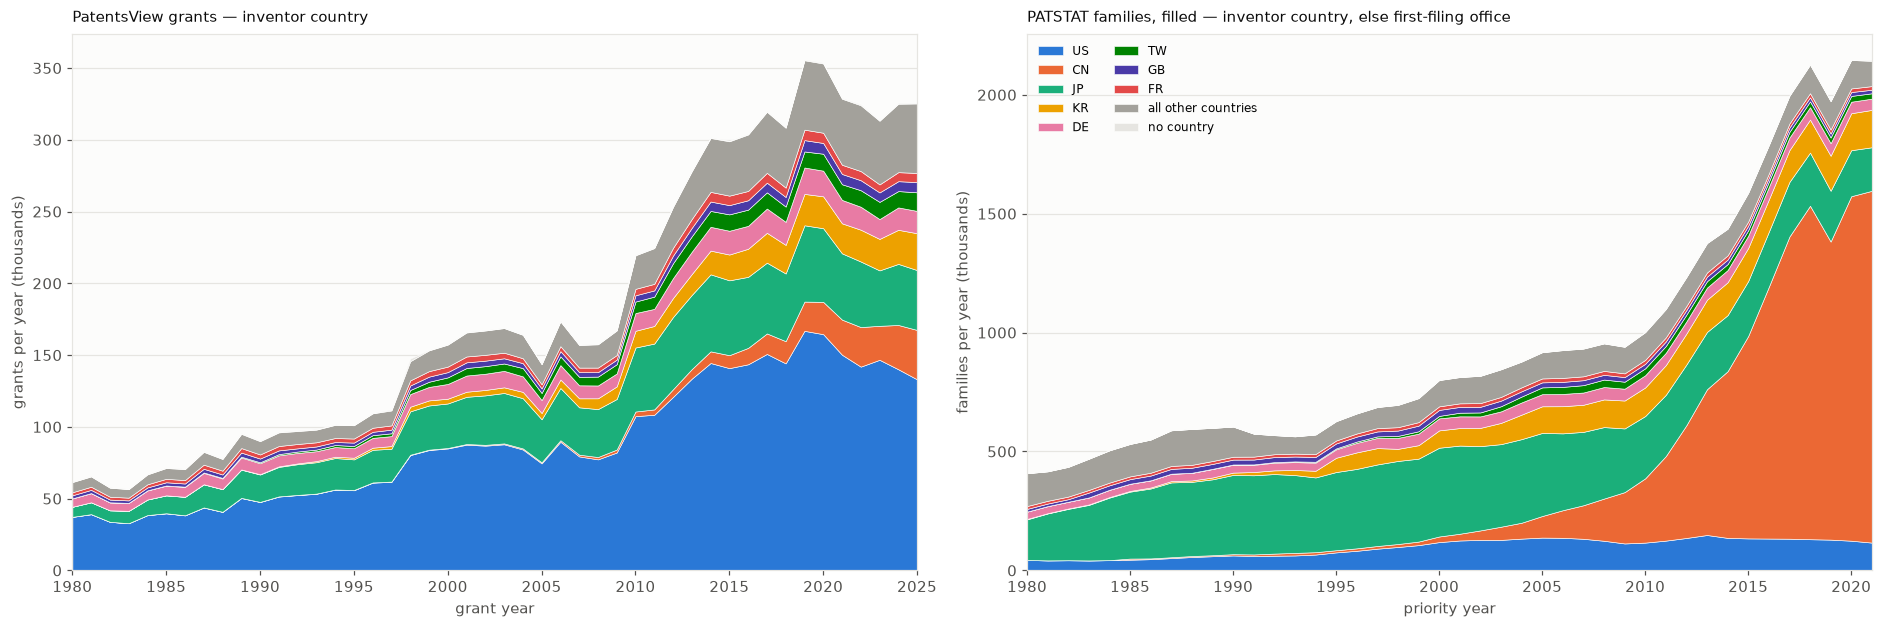

PatentsView grants                 PATSTAT families, filled          \
year                2000    2010    2019                     2000    2010   
US                 84959  107471  166905                   118987  116862   
CN                   325    3223   20369                    23630  270345   
JP                 31020   44583   53168                   373232  261929   
KR                  3317   11665   21868                    72938  120126   
DE                 10274   12365   18402                    50566   51458   
TW                  4592    7994   11169                    10340   29112   
GB                  3661    4369    7894                    25114   18956   
FR                  3839    4481    7291                    15044   16336   
other              15325   23383   48361                   110427  116636   

                
year      2019  
US      129398  
CN     1253368  
JP      213676  
KR      147168  
DE       52662  
TW       23943  
GB       16497  
FR       17043  
other   119147

CPU times: user 3.27 s, sys: 82.8 ms, total: 3.35 s
Wall time: 1.68 s


In [4]:
%%time
def counts(k):
    d = q(f'SELECT year, country, w FROM w_{k} WHERE year BETWEEN {FIRST[k]} AND {LAST[k]}')
    c = d.pivot_table(index='year', columns='country', values='w', aggfunc='sum').fillna(0)
    out = pd.DataFrame({cc: c[cc] if cc in c else 0.0 for cc in TOP8}, index=c.index)
    out['other'] = c.drop(columns=[x for x in TOP8 if x in c]).sum(axis=1)
    return out
none_pf = q(f"""SELECT year, count(*) AS n FROM pf WHERE year BETWEEN {Y0} AND {SNAP_PS} AND n_located = 0
               AND NOT (regexp_full_match(office, '[A-Z]{{2}}') AND office NOT IN {REGIONAL}) GROUP BY 1""").set_index('year').n
none_pv = q(f"SELECT year, count(*) AS n FROM pv WHERE n_located = 0 GROUP BY 1").set_index('year').n
fig, ax = plt.subplots(1, 2, figsize=(17, 5.6), layout='constrained')
for a, k, none, unit in ((ax[0], 'pv', none_pv, 'grants'), (ax[1], 'pff', none_pf, 'families')):
    c = counts(k)
    c['no country'] = none.reindex(c.index).fillna(0)
    cols = [COLOR[x] for x in TOP8] + [OTHER, UNLOC]
    a.stackplot(c.index, (c / 1e3).T.to_numpy(), labels=TOP8 + ['all other countries', 'no country'], colors=cols,
                edgecolor=SURFACE, linewidth=0.4)
    style(a, YEAR_LABEL[k], f'{unit} per year (thousands)', SERIES[k][0] + (' — inventor country, else first-filing office' if k == 'pff' else ' — inventor country'))
    a.set_xlim(c.index.min(), c.index.max())
ax[1].legend(frameon=False, fontsize=8, ncol=2, loc='upper left')
V.save('2', tight=False)
tab = pd.concat({SERIES[k][0]: counts(k).loc[[2000, 2010, 2019]].T.round(0) for k in ('pv', 'pff')}, axis=1)
display(tab.astype(int))

## 3. Country shares over time — four ways of counting

One panel per country (the twelve largest in either view, 2010–2019), each with the four series: share of located
inventive output, fractional counting. Within a panel, **PatentsView vs the families** is the US lens (countries that
patent heavily in the US look larger there), **applications vs families** is multi-office filing (an inventor base that
files each invention at many offices counts many times as applications), and **families vs filled families** is the
missing-address correction, which matters for China, Japan and Korea only. Each panel has its own y-scale.

  [fig] patent_country_validation_3.jpg + .pdf  (600 dpi)


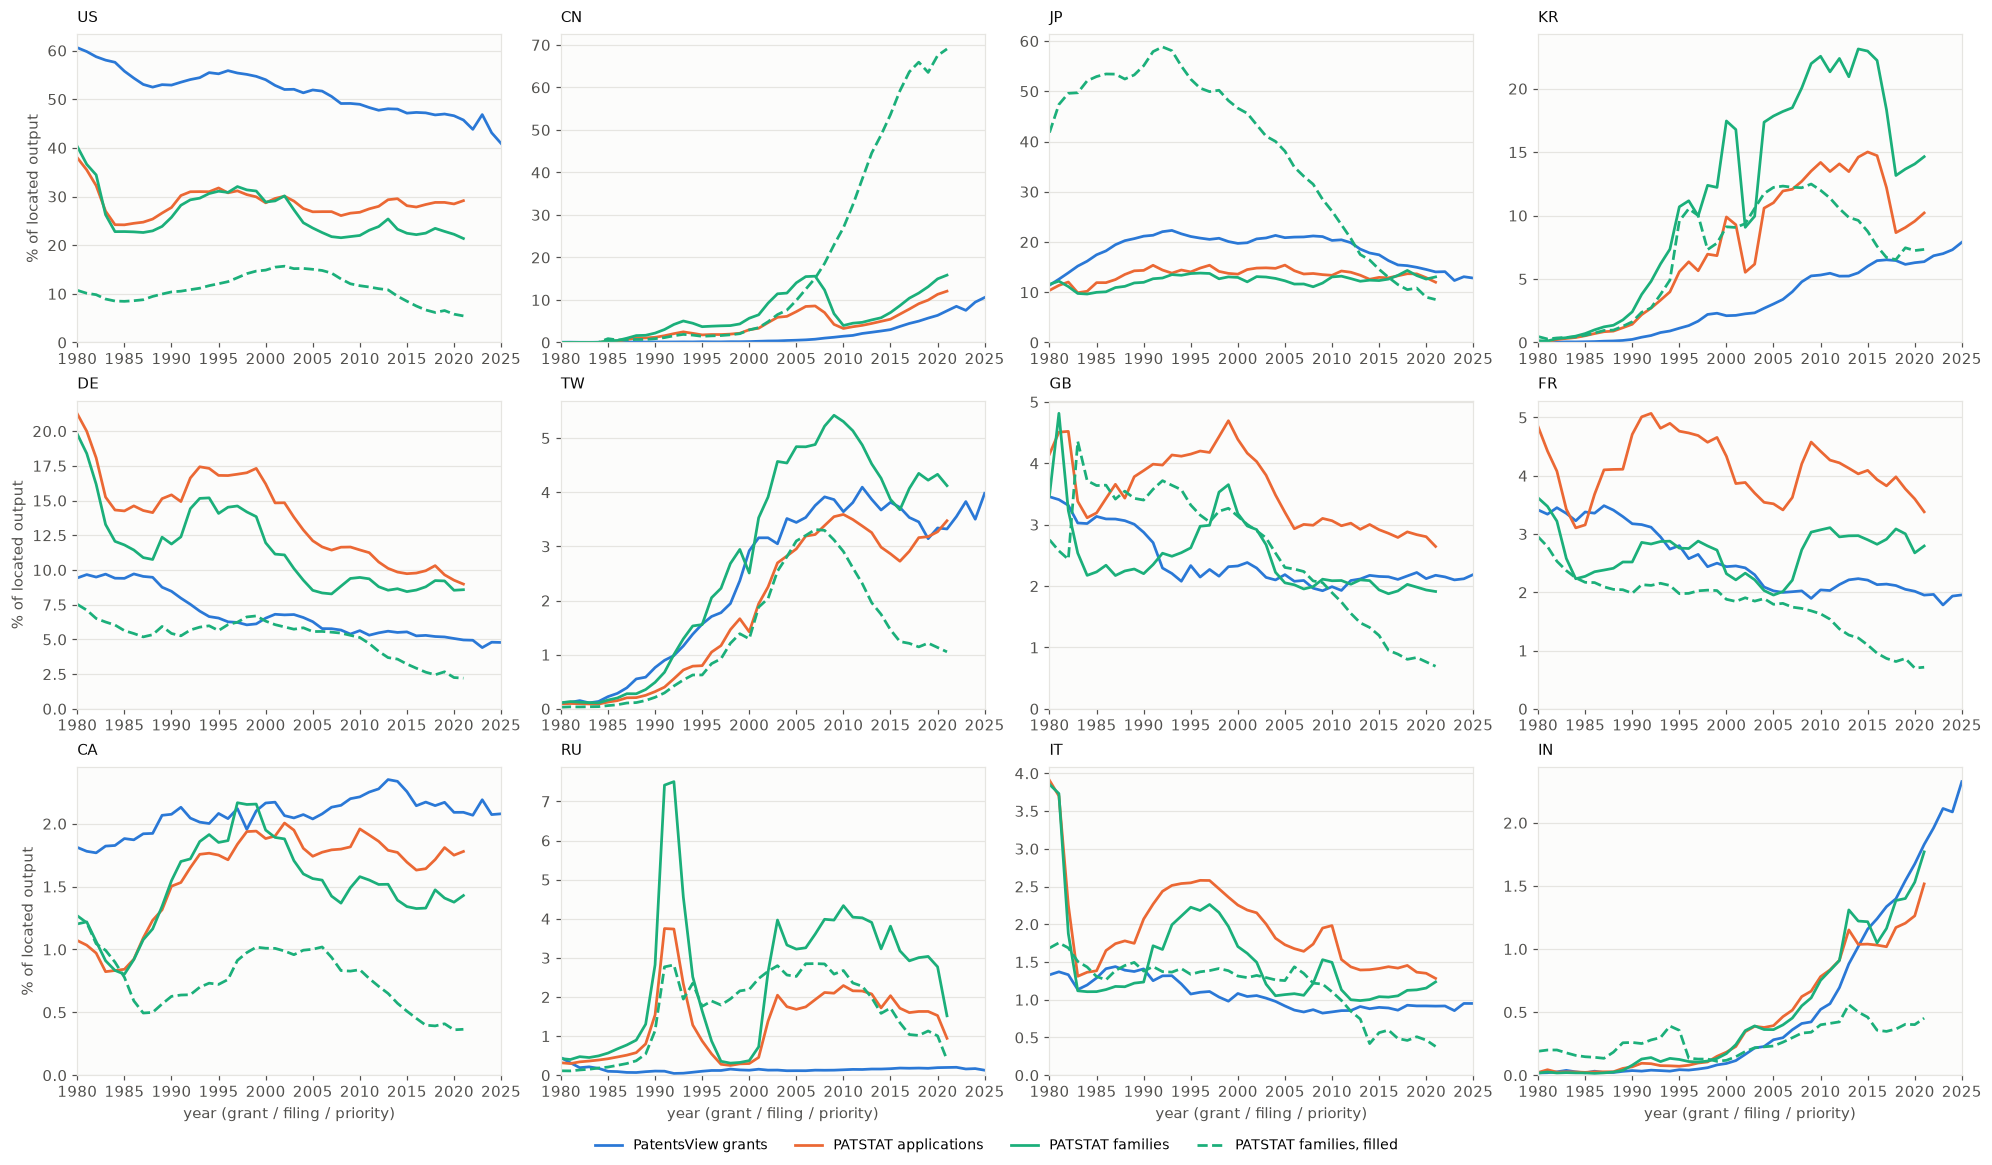

mean share 2010-2019 (%):


,PatentsView grants,PATSTAT applications,PATSTAT families,"PATSTAT families, filled"
country,,,,
US,47.63,28.30,23.09,8.98
CN,3.23,5.95,7.52,49.70
JP,17.64,13.40,12.95,16.46
KR,5.83,12.94,20.07,9.04
DE,5.40,10.27,8.90,3.52
TW,3.67,3.15,4.43,1.78
GB,2.11,2.93,2.01,1.26
FR,2.13,4.07,2.98,1.16
CA,2.23,1.78,1.44,0.57


CPU times: user 3.9 s, sys: 133 ms, total: 4.03 s
Wall time: 4.05 s


In [5]:
%%time
T12 = list(dict.fromkeys(TOP8 + list(comb.nlargest(16).index)))[:12]
fig, axes = plt.subplots(3, 4, figsize=(18, 10.5), layout='constrained')
for ax, c in zip(axes.flat, T12):
    for k in SERIES:
        lab, col, ls = SERIES[k]
        if c in S[k]:
            ax.plot(S[k].index, S[k][c], lw=1.8, color=col, ls=ls, label=lab)
    style(ax, None, None, c)
    ax.set_ylim(bottom=0); ax.set_xlim(Y0, PV_LAST)
for ax in axes[:, 0]:
    ax.set_ylabel('% of located output', color=MUTED)
for ax in axes[-1, :]:
    ax.set_xlabel('year (grant / filing / priority)', color=MUTED)
h, l = axes.flat[0].get_legend_handles_labels()
fig.legend(h, l, loc='outside lower center', ncol=4, frameon=False, fontsize=9)
V.save('3', tight=False)
print('mean share 2010-2019 (%):')
display(pd.DataFrame({SERIES[k][0]: recent(k).reindex(T12) for k in SERIES}).round(2))

## 4. Country shares, 2010–2019, compared

The mean 2010–2019 shares of the twenty largest countries of the filled family series, as grouped bars on a log scale
(so the small producers stay readable). The hatched bar is the filled family series.

  [fig] patent_country_validation_4.jpg + .pdf  (600 dpi)


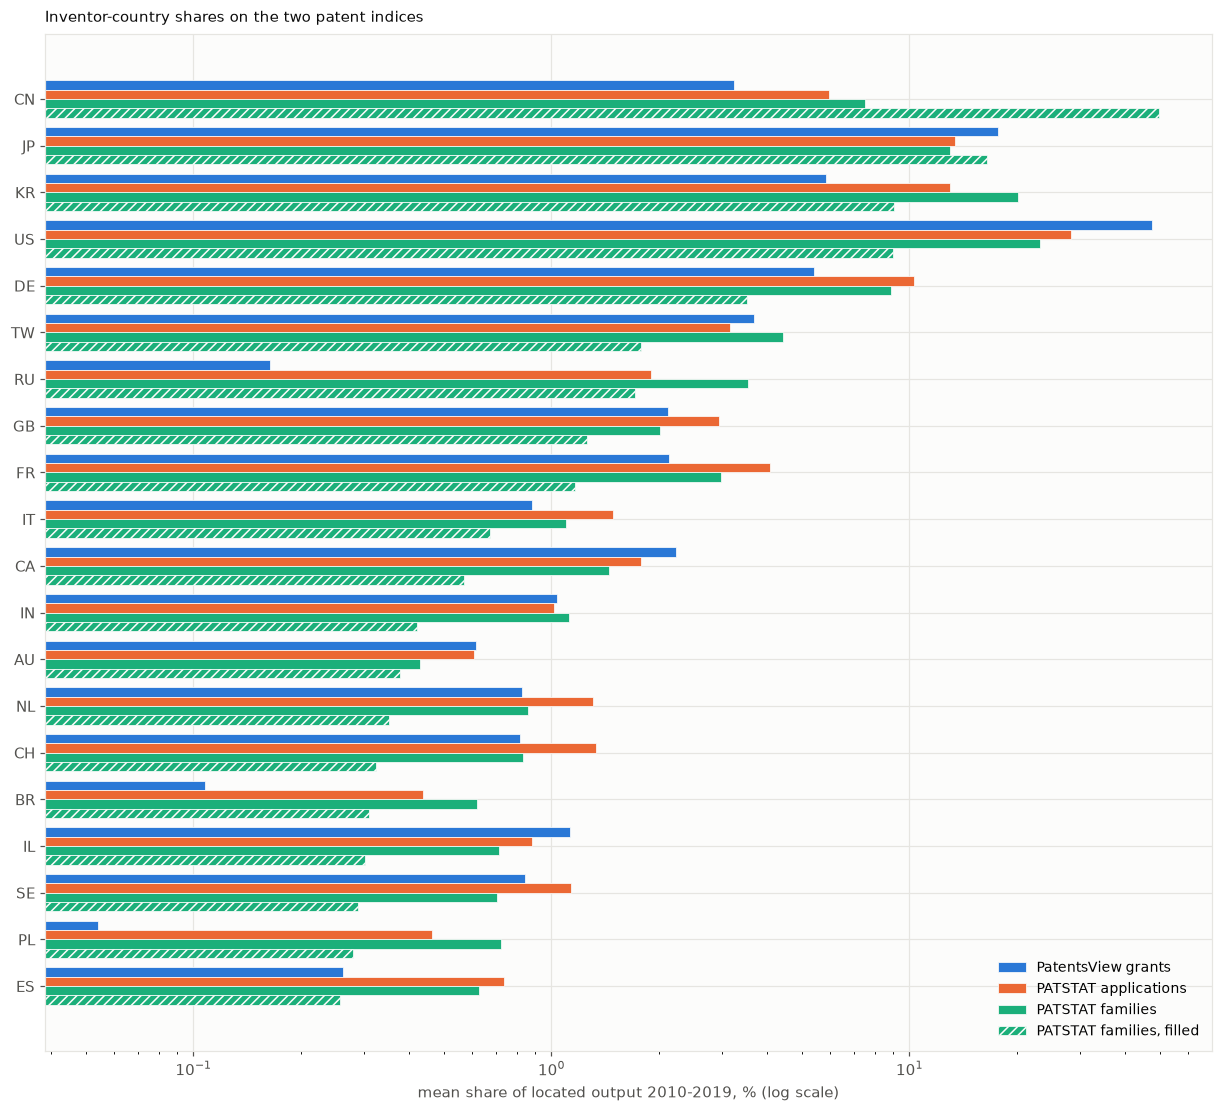

,PatentsView grants,PATSTAT applications,PATSTAT families,"PATSTAT families, filled"
country,,,,
CN,3.23,5.95,7.52,49.70
JP,17.64,13.40,12.95,16.46
KR,5.83,12.94,20.07,9.04
US,47.63,28.30,23.09,8.98
DE,5.40,10.27,8.90,3.52
TW,3.67,3.15,4.43,1.78
RU,0.16,1.90,3.55,1.71
GB,2.11,2.93,2.01,1.26
FR,2.13,4.07,2.98,1.16


CPU times: user 1.47 s, sys: 89.9 ms, total: 1.56 s
Wall time: 1.57 s


In [6]:
%%time
T20 = recent('pff').nlargest(20).index.tolist()
tab = pd.DataFrame({k: recent(k).reindex(T20).fillna(0) for k in SERIES})
fig, ax = plt.subplots(figsize=(11, 10), layout='constrained')
y = np.arange(len(T20)); h = 0.2
for i, k in enumerate(SERIES):
    lab, col, _ = SERIES[k]
    ax.barh(y + (i - 1.5) * h, tab[k].clip(lower=1e-3), height=h, color=col, label=lab, edgecolor=SURFACE, linewidth=0.5,
            hatch='////' if k == 'pff' else None)
ax.set_yticks(y); ax.set_yticklabels(T20); ax.invert_yaxis(); ax.set_xscale('log')
style(ax, 'mean share of located output 2010-2019, % (log scale)', None, 'Inventor-country shares on the two patent indices')
ax.grid(axis='x', color=GRID, lw=.8); ax.legend(frameon=False, fontsize=9, loc='lower right')
V.save('4', tight=False)
display(tab.rename(columns={k: SERIES[k][0] for k in SERIES}).round(2))

## 5. World maps — share of world patenting, 2015–2019

Fractional counting on a shared log scale: (a) PatentsView grants by grant year, (b) PATSTAT applications by filing
year, located only, (c) PATSTAT families by priority year, filled. Panel (b) is drawn to show what a located-only
PATSTAT count does to China and Japan; (c) is the worldwide picture. (d) is the US lens as a ratio,
log₂(PatentsView share / PATSTAT family share): red countries are over-represented in US grants relative to their
worldwide inventive output, blue ones under-represented. Grey is "no value", not zero; the ratio needs at least 50
grants and 200 families.

  [fig] patent_country_validation_5.jpg + .pdf  (600 dpi)


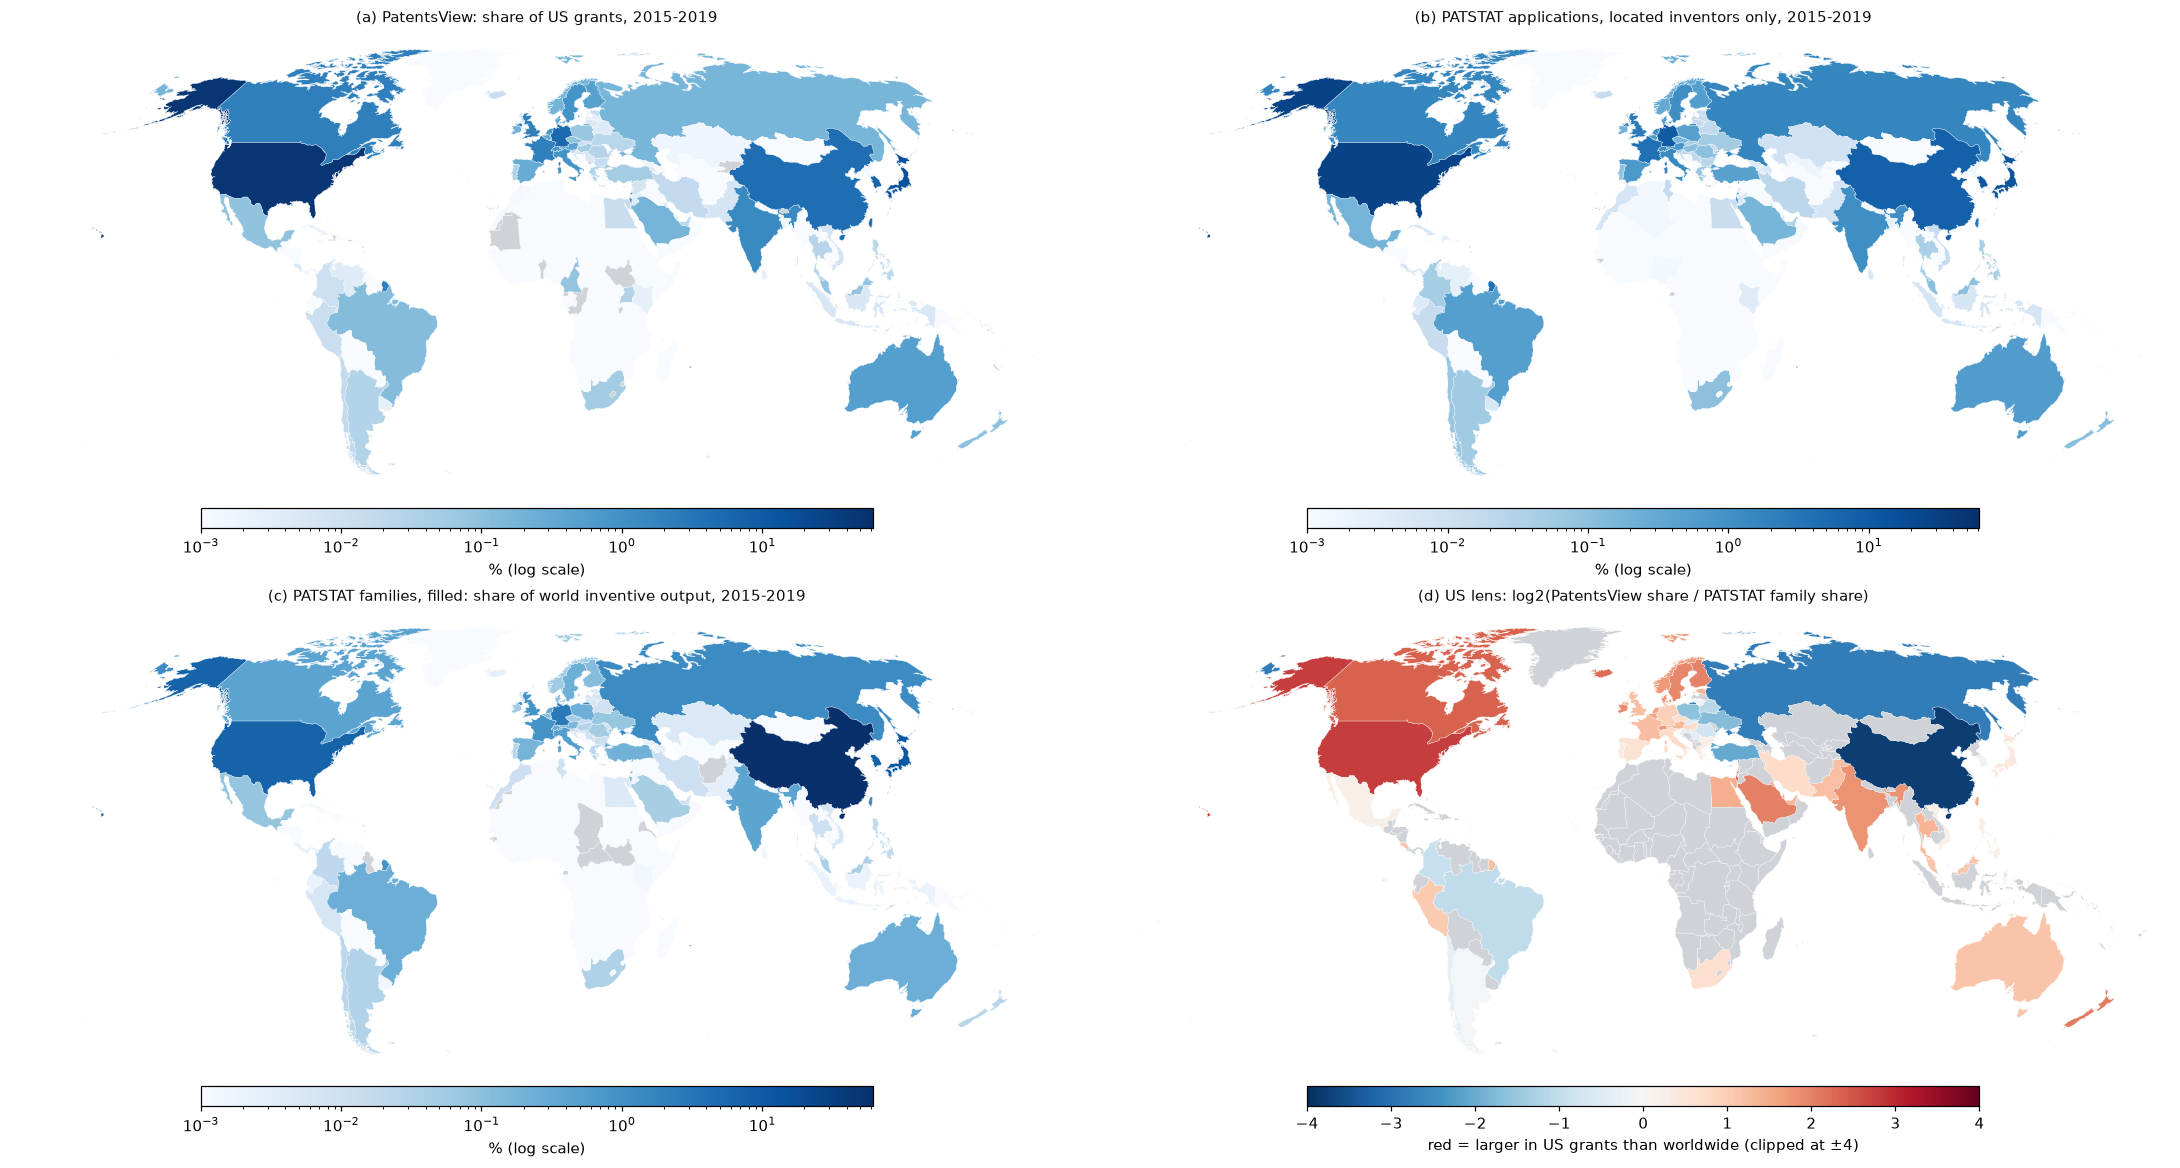

  1 PatentsView grants code(s) have no polygon on the map (0.00% of the total): GI
  56 PATSTAT applications code(s) have no polygon on the map (0.00% of the total): AB, AN, AP, AQ, BC, BQ, BU, BV, CS, CT, DD, EA, EN, EP, FE, FL, FN, FX, GF, GI
  39 PATSTAT families, filled code(s) have no polygon on the map (0.00% of the total): AN, AP, BC, BU, BV, CT, DD, EP, FL, GF, GI, GP, KA, MI, MQ, NX, NY, OA, OH, OK


,PatentsView %,PATSTAT applications (located) %,PATSTAT families (filled) %,log2 PV / families
country,,,,
CN,4.450,7.785,61.617,-3.791
JP,15.842,13.278,11.931,0.409
KR,6.313,11.984,7.329,-0.215
US,47.065,28.369,6.993,2.751
DE,5.290,9.881,2.756,0.941
TW,3.519,2.964,1.244,1.501
RU,0.178,1.723,1.224,-2.785
GB,2.162,2.858,0.923,1.228
FR,2.127,3.922,0.909,1.227


CPU times: user 7.19 s, sys: 522 ms, total: 7.71 s
Wall time: 7.99 s


In [7]:
%%time
from matplotlib.colors import LogNorm, TwoSlopeNorm
world, PTS = load_world()
if world is None:
    print('[skip 5] no world geometry available')
else:
    def win(k, y0=2015, y1=2019):
        return q(f'SELECT country, sum(w) AS w FROM w_{k} WHERE year BETWEEN {y0} AND {y1} GROUP BY 1').set_index('country').w
    W5 = {k: win(k) for k in ('pv', 'pa', 'pff')}
    SH = {k: 100 * v / v.sum() for k, v in W5.items()}
    both = pd.concat([W5['pv'].rename('pv'), W5['pff'].rename('pf')], axis=1).fillna(0)
    ok = both[(both.pv >= 50) & (both.pf >= 200)].index
    ratio = np.log2(SH['pv'].reindex(ok) / SH['pff'].reindex(ok)).clip(-4, 4)
    lo = 1e-3; hi = max(s.max() for s in SH.values())
    fig, axes = plt.subplots(2, 2, figsize=(20, 10.5), layout='constrained')
    choropleth(axes[0, 0], world, SH['pv'], '(a) PatentsView: share of US grants, 2015-2019', '% (log scale)', norm=LogNorm(vmin=lo, vmax=hi))
    choropleth(axes[0, 1], world, SH['pa'], '(b) PATSTAT applications, located inventors only, 2015-2019', '% (log scale)', norm=LogNorm(vmin=lo, vmax=hi))
    choropleth(axes[1, 0], world, SH['pff'], '(c) PATSTAT families, filled: share of world inventive output, 2015-2019', '% (log scale)', norm=LogNorm(vmin=lo, vmax=hi))
    choropleth(axes[1, 1], world, ratio, '(d) US lens: log2(PatentsView share / PATSTAT family share)',
               'red = larger in US grants than worldwide (clipped at ±4)', cmap=DIV, norm=TwoSlopeNorm(vcenter=0, vmin=-4, vmax=4))
    V.save('5', tight=False)
    for k in W5:
        map_coverage(W5[k], world, SERIES[k][0])
    top = pd.DataFrame({'PatentsView %': SH['pv'], 'PATSTAT applications (located) %': SH['pa'],
                        'PATSTAT families (filled) %': SH['pff'], 'log2 PV / families': np.log2(SH['pv'] / SH['pff'])}).reindex(SH['pff'].nlargest(15).index)
    display(top.round(3))

## 6. Where filed against where invented

PATSTAT families with located inventors, priority 2010–2019: each row is an office of first filing, each column an
inventor country, and a cell is the share (fractional) of that office's located first filings invented in that
country. National offices are mostly domestic; the EPO and the PCT route (WO) are where cross-border inventive
activity is first filed. Offices whose inventors are rarely located (CN, JP) enter with their located minority only —
see §1.

  [fig] patent_country_validation_6.jpg + .pdf  (600 dpi)


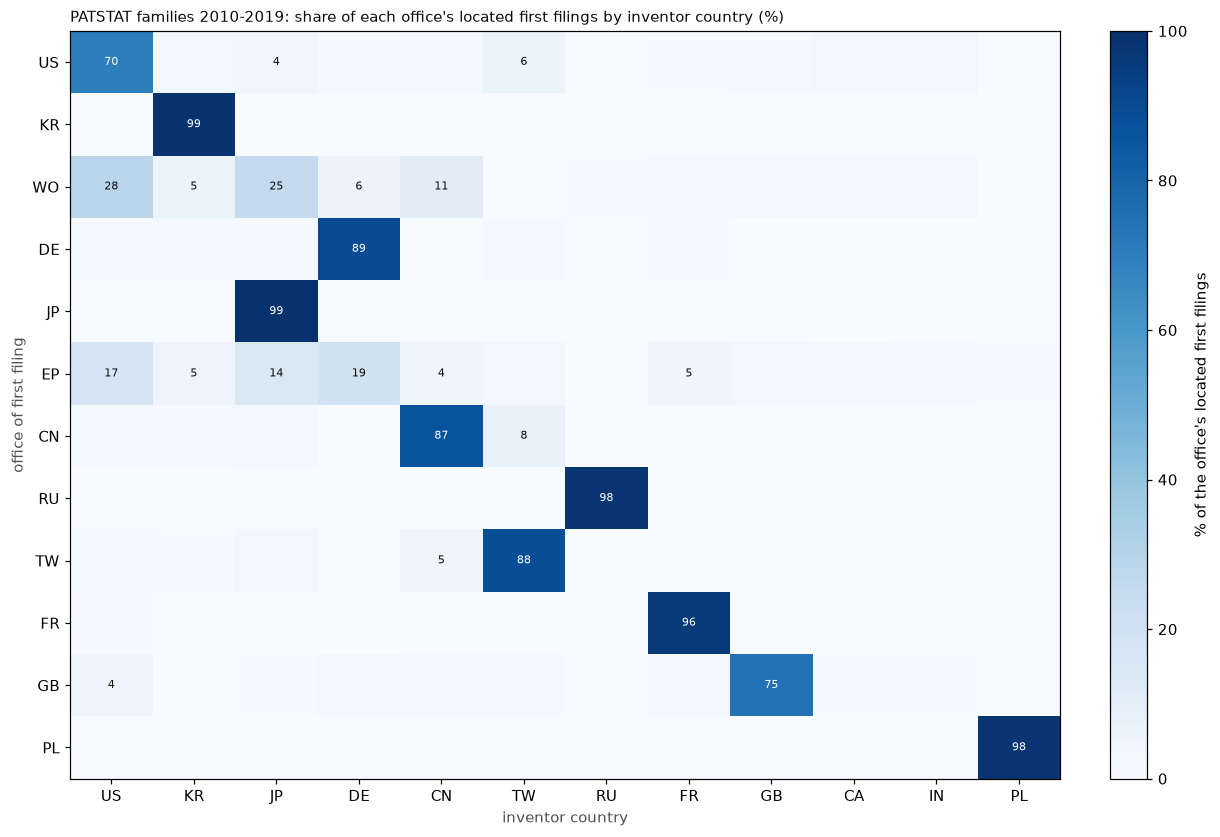

,located families,domestic %
US,1369299.0,69.8
KR,1049769.0,98.7
WO,1010902.0,0.0
DE,409876.0,89.3
JP,376485.0,99.0
EP,307797.0,0.0
CN,302826.0,86.6
RU,196676.0,98.1
TW,146914.0,88.4
FR,134305.0,96.1


CPU times: user 5.18 s, sys: 952 ms, total: 6.13 s
Wall time: 4.99 s


In [8]:
%%time
fo = q("""SELECT office, split_part(x, ':', 1) AS country, sum(split_part(x, ':', 2)::DOUBLE / n_located) AS w
   FROM (SELECT office, n_located, unnest(str_split(cic, ';')) AS x FROM pf WHERE n_located > 0 AND year BETWEEN 2010 AND 2019)
   GROUP BY 1, 2""")
mat = fo.pivot_table(index='office', columns='country', values='w', aggfunc='sum').fillna(0)
rows_ = mat.sum(axis=1).nlargest(12).index
cols_ = mat.loc[rows_].sum(axis=0).nlargest(12).index
share = mat.loc[rows_].div(mat.loc[rows_].sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(11, 7.5), layout='constrained')
im = ax.imshow(share[cols_].to_numpy(), cmap=SEQ, aspect='auto', vmin=0, vmax=100)
ax.set_xticks(range(len(cols_))); ax.set_xticklabels(cols_); ax.set_yticks(range(len(rows_))); ax.set_yticklabels(rows_)
vals = share[cols_].to_numpy()
for i in range(len(rows_)):
    for j in range(len(cols_)):
        if vals[i, j] >= 3:
            ax.text(j, i, f'{vals[i, j]:.0f}', ha='center', va='center', fontsize=7, color='white' if vals[i, j] > 55 else INK)
ax.set_xlabel('inventor country', color=MUTED); ax.set_ylabel('office of first filing', color=MUTED)
ax.set_title("PATSTAT families 2010-2019: share of each office's located first filings by inventor country (%)", fontsize=10, color=INK, loc='left')
plt.colorbar(im, ax=ax, fraction=0.04, label="% of the office's located first filings")
V.save('6', tight=False)
dom = pd.Series({o: share.loc[o].get(o, np.nan) for o in rows_}, name='domestic %')
display(pd.DataFrame({'located families': mat.loc[rows_].sum(axis=1).round(0), 'domestic %': dom.round(1)}))

## 7. International co-invention

Share of located multi-inventor documents whose located inventors sit in at least two countries. Left: by year on the
three series. Right: the rate for the fifteen largest inventor countries of the family series in 2010–2019 — a
document counts for every country among its inventors — on PatentsView and on PATSTAT families. A country's
PatentsView rate is the rate of its *US-patented* inventions, which are selected toward the international ones.

  [fig] patent_country_validation_7.jpg + .pdf  (600 dpi)


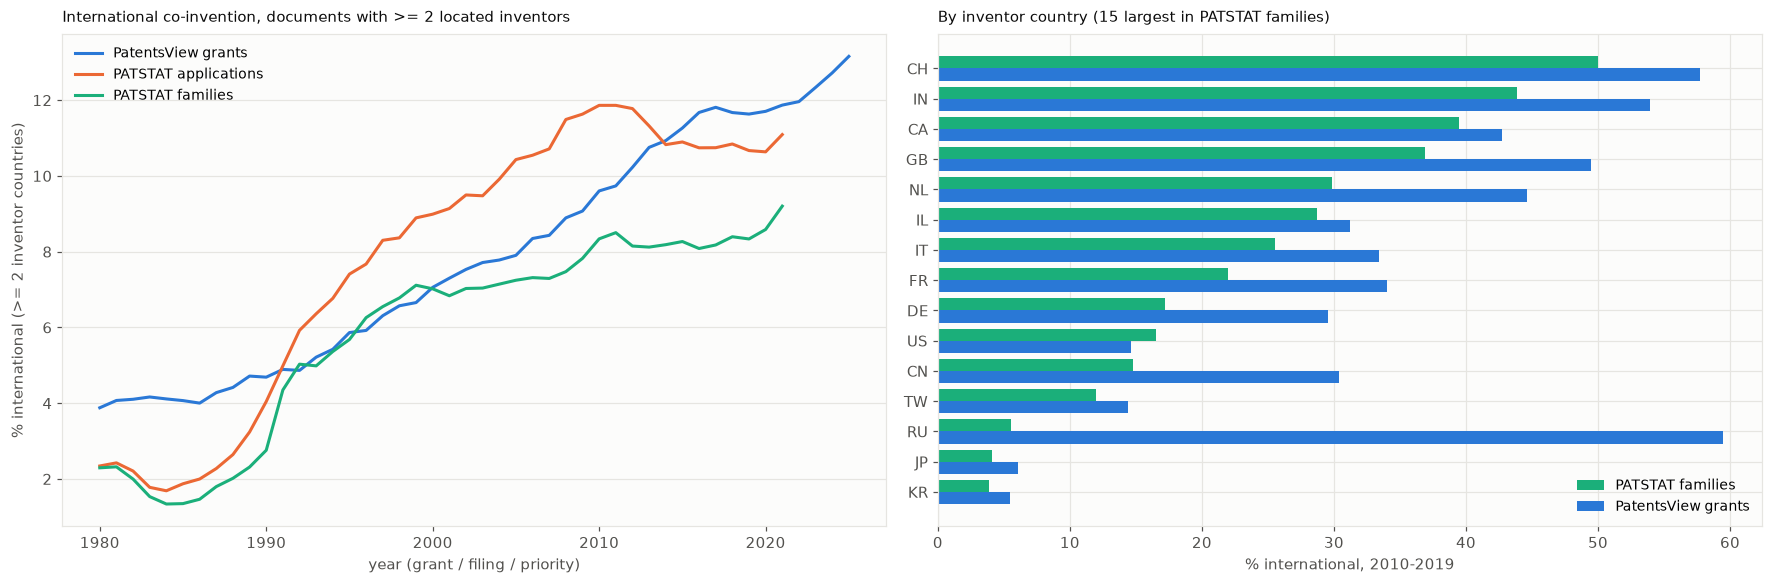

,pf_n,pf_pct,pv_n,pv_pct
country,,,,
KR,640542.0,3.8,131520.0,5.5
JP,504984.0,4.1,332706.0,6.1
RU,148977.0,5.6,5310.0,59.4
TW,161916.0,12.0,74242.0,14.4
CN,314175.0,14.8,84300.0,30.4
US,1004584.0,16.5,1039326.0,14.6
DE,359673.0,17.2,134140.0,29.5
FR,129693.0,22.0,57283.0,34.0
IT,40880.0,25.6,21495.0,33.4


CPU times: user 2.61 s, sys: 75.7 ms, total: 2.68 s
Wall time: 1.42 s


In [9]:
%%time
ty = {k: q(f"""SELECT year, 100.0 * avg(intl::INT) AS pct FROM {k} WHERE n_located >= 2
               AND year BETWEEN {FIRST[k]} AND {LAST[k]} GROUP BY 1 ORDER BY 1""") for k in ('pv', 'pa', 'pf')}
def by_country(t):
    return q(f"""SELECT split_part(x, ':', 1) AS country, count(*) AS n, 100.0 * avg(intl::INT) AS pct
        FROM (SELECT intl, unnest(str_split(cic, ';')) AS x FROM {t} WHERE n_located >= 2 AND year BETWEEN 2010 AND 2019)
        GROUP BY 1""").set_index('country')
bc = pd.concat([by_country('pv').add_prefix('pv_'), by_country('pf').add_prefix('pf_')], axis=1)
top = bc.pf_n.nlargest(15).index
fig, ax = plt.subplots(1, 2, figsize=(16, 5.2), layout='constrained')
for k in ('pv', 'pa', 'pf'):
    ax[0].plot(ty[k].year, ty[k].pct, lw=2, color=SERIES[k][1], label=SERIES[k][0])
style(ax[0], 'year (grant / filing / priority)', '% international (>= 2 inventor countries)',
      'International co-invention, documents with >= 2 located inventors'); ax[0].legend(frameon=False, fontsize=9)
b = bc.loc[top].sort_values('pf_pct'); yv = np.arange(len(b))
ax[1].barh(yv + 0.2, b.pf_pct, height=0.4, color=AQUA, label='PATSTAT families')
ax[1].barh(yv - 0.2, b.pv_pct, height=0.4, color=BLUE, label='PatentsView grants')
ax[1].set_yticks(yv); ax[1].set_yticklabels(b.index)
style(ax[1], '% international, 2010-2019', None, 'By inventor country (15 largest in PATSTAT families)')
ax[1].grid(axis='x', color=GRID, lw=.8); ax[1].legend(frameon=False, fontsize=9, loc='lower right')
V.save('7', tight=False)
display(b[['pf_n', 'pf_pct', 'pv_n', 'pv_pct']].round(1))

## 8. Cross-check — the same office in both indices

PATSTAT holds the USPTO's applications too, so its granted US applications, dated by grant year, are the PatentsView
grants seen through a second pipeline (`patstat_validation` §16 matches them patent by patent: 99.1 % have the same
inventor-country set). (a) Their 2010–2019 country shares against PatentsView's: the points must lie on the diagonal.
(b) For contrast, PATSTAT families (filled) against PatentsView: the spread around the diagonal is the US lens of §5(d),
not an error. Log–log, every country with a share above 0.001 % in both; Spearman over the same countries.

  [fig] patent_country_validation_8.jpg + .pdf  (600 dpi)


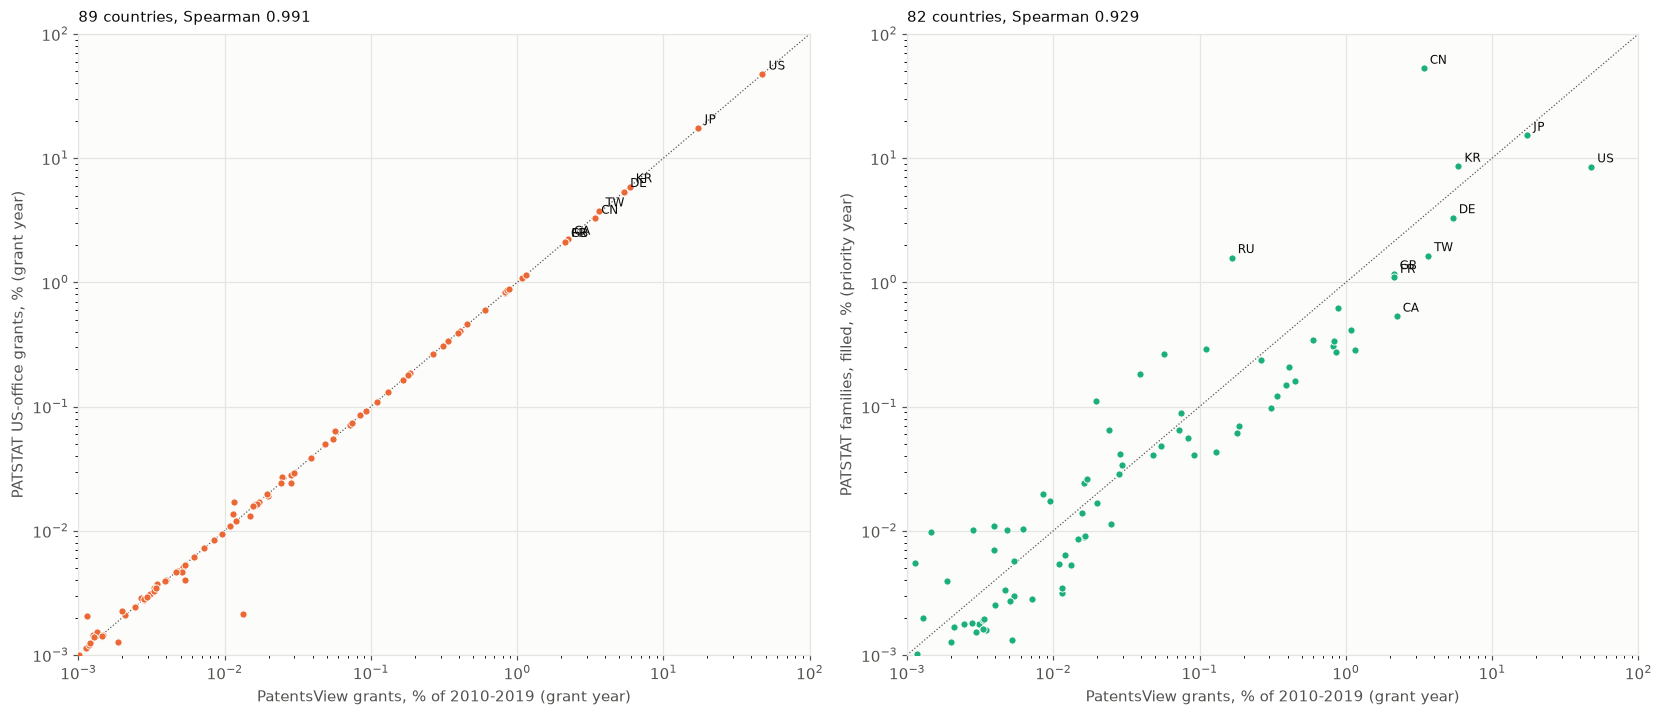

,PatentsView %,PATSTAT US-office grants %,PATSTAT families (filled) %
country,,,
US,47.553,47.390,8.493
JP,17.373,17.527,15.248
KR,5.881,5.872,8.600
DE,5.385,5.384,3.313
TW,3.652,3.758,1.640
CN,3.413,3.274,52.822
CA,2.228,2.224,0.533
FR,2.133,2.129,1.096
GB,2.121,2.130,1.172


{'PATSTAT US-office grants, % (grant year)': np.float64(0.991), 'PATSTAT families, filled, % (priority year)': np.float64(0.9293)}
CPU times: user 7.66 s, sys: 692 ms, total: 8.35 s
Wall time: 5.53 s


In [10]:
%%time
from scipy.stats import spearmanr
con.execute(f"""CREATE OR REPLACE TABLE pus AS
  SELECT m.grant_year AS year, ic.country_inventor_counts AS cic, ic.n_located
  FROM read_parquet('{V.patstat('patstat_metadata.parquet')}') m
  JOIN read_parquet('{V.patstat('patstat_inventor_country.parquet')}') ic USING (appln_id)
  WHERE m.appln_auth = 'US' AND m.granted AND m.grant_year BETWEEN 2010 AND 2019 AND ic.n_located > 0""")
con.execute(f"CREATE OR REPLACE TABLE w_pus AS {weights('pus')}")
def win_share(k, y0=2010, y1=2019):
    d = q(f'SELECT country, sum(w) AS w FROM w_{k} WHERE year BETWEEN {y0} AND {y1} GROUP BY 1').set_index('country').w
    return 100 * d / d.sum()
pv_s, pus_s, pff_s = win_share('pv'), win_share('pus'), win_share('pff')
fig, ax = plt.subplots(1, 2, figsize=(15, 6.4), layout='constrained')
rho = {}
for a, other, lab, col in ((ax[0], pus_s, 'PATSTAT US-office grants, % (grant year)', ORANGE),
                           (ax[1], pff_s, 'PATSTAT families, filled, % (priority year)', AQUA)):
    d = pd.concat([pv_s.rename('pv'), other.rename('o')], axis=1).dropna()
    d = d[(d.pv > 1e-3) & (d.o > 1e-3)]
    rho[lab] = spearmanr(d.pv, d.o).correlation
    a.scatter(d.pv, d.o, s=22, color=col, edgecolor=SURFACE, linewidth=0.6, zorder=3)
    lim = (1e-3, 100); a.plot(lim, lim, color=MUTED, lw=.8, ls=':')
    for c in d.pv.nlargest(8).index.union(d.o.nlargest(8).index):
        a.annotate(c, (d.pv[c], d.o[c]), xytext=(4, 3), textcoords='offset points', fontsize=8, color=INK)
    a.set_xscale('log'); a.set_yscale('log'); a.set_xlim(lim); a.set_ylim(lim)
    style(a, 'PatentsView grants, % of 2010-2019 (grant year)', lab, f'{len(d)} countries, Spearman {rho[lab]:.3f}')
    a.grid(axis='x', color=GRID, lw=.8)
V.save('8', tight=False)
cmp = pd.DataFrame({'PatentsView %': pv_s, 'PATSTAT US-office grants %': pus_s, 'PATSTAT families (filled) %': pff_s}).reindex(pv_s.nlargest(15).index)
display(cmp.round(3))
print({k: round(v, 4) for k, v in rho.items()})
# the same grants read by two pipelines: a gross-error check, not a tuned threshold
assert rho['PATSTAT US-office grants, % (grant year)'] > 0.9, 'country shares of the same US grants disagree between the indices'